In [1]:
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import tqdm
import seaborn as sns

## Load the temperature and solar data

In [2]:
#Load the solar data

data_dir = Path('/g/data/gb02/cd3022/hot-and-cloudy/solar-pv/GCCSA/ideal-actual')
files = list(data_dir.glob("*.nc"))
datasets = []

for file in files:
    region_name = file.stem[1:5]
    ds_reg = xr.open_dataset(file)
    ds_reg = ds_reg.expand_dims(region=[region_name])

    datasets.append(ds_reg)

ds = xr.concat(datasets, dim='region')

In [3]:
# Change times to AEST, remove bad days, convert to capacity factor
time_utc = pd.to_datetime(ds.time.values)
time_aest = time_utc.tz_localize("UTC").tz_convert("Australia/Brisbane")
time_aest_naive = time_aest.tz_convert("Australia/Brisbane").tz_localize(None)
ds = ds.assign_coords(time=("time", time_aest_naive))

ds = ds.where(ds['time'].dt.strftime('%H:%M') != '12:40', drop=True)

bad_days = [
    np.datetime64('2019-08-12'),
    np.datetime64('2019-10-01'),
    np.datetime64('2020-09-06'),
    
]
ds_dates = ds['time'].dt.floor('D')
good_time_mask = ~ds_dates.isin(bad_days)
ds = ds.sel(time=ds['time'][good_time_mask])

rated_capacity = 219.656729124
ds = ds.apply(lambda x: x / rated_capacity)

ds = xr.where(ds.isnull(), 0, ds)

# Daily cloudiness
Integrate the actual and ideal data over a given period of time from *a* to *b*, then use the ratio of the two as the measure for daily cloudiness:

$${\text{CSI}}_{\text{integrated}} = \frac{\int_{a}^{b} {P_\text{actual}(t)} \ dt}{\int_{a}^{b} {P_\text{ideal}(t)} \ dt}$$

In [123]:
# Choose bounds for the time of interest
time_of_interest = (10, 17)

# get just the data for time of interest
mask = (ds.time.dt.hour >= time_of_interest[0]) & (ds.time.dt.hour < time_of_interest[1])
ds_time_of_interest = ds.where(mask)

# Integrate over each day between 10am and 5pm
# daily_actual_time_of_interest = ds_time_of_interest['actual'].resample(time='1D').map(
#     lambda x: x.fillna(0).integrate(coord='time')
# )
# daily_ideal_time_of_interest = ds_time_of_interest['ideal'].resample(time='1D').map(
#     lambda x: x.fillna(0).integrate(coord='time')
# )

daily_actual_time_of_interest = ds_time_of_interest['actual'].groupby('time.date').map(
    lambda x: x.fillna(0).integrate(coord='time')
)
daily_ideal_time_of_interest = ds_time_of_interest['ideal'].groupby('time.date').map(
    lambda x: x.fillna(0).integrate(coord='time')
)

# Take the ratio of the two integrated variables to get the integrated CSI
CSI_integrated = daily_actual_time_of_interest / daily_ideal_time_of_interest

In [12]:
#Load the BARRA temperature data over the same regions
tas = xr.open_mfdataset("/g/data/gb02/ad1803/Hot & Cloudy/Temp_Greater_Metro/tas/tas_barra-c2_hourly_2015-2023_FILTERED_????.nc")["tas"].persist()
time_utc = pd.to_datetime(tas.time.values)
time_aest = time_utc.tz_localize("UTC").tz_convert("Australia/Brisbane")
time_aest_naive = time_aest.tz_convert("Australia/Brisbane").tz_localize(None)
tas = tas.assign_coords(time=("time", time_aest_naive))
tas = tas - 273.15
tas["region"] = ["GSYD","GMEL","GBRI","GADE","GHOB","ACTE"]

## Resample to daily, Nov-Apr 2015-2023, and merge

In [115]:
#Daily max for temperature
tas_daily = tas.resample({"time":"1D"}).max()


# Keep track of the number of non-missing CSI values for each day during the time of interest
CSI = ds.actual / ds.ideal
csi_not_missing = (~CSI.sel(time=(CSI.time.dt.hour >= 12) & (CSI.time.dt.hour < 17)).isnull()).groupby("time.date").sum()

In [125]:
#Restrict the data to Nov-Apr
tas_daily = tas_daily.sel(time=np.in1d(tas_daily.time.dt.month,[11,12,1,2,3,4]))

CSI_integrated = CSI_integrated.sel(date=np.in1d(pd.to_datetime(CSI_integrated.date).month,[11,12,1,2,3,4]))
csi_not_missing = csi_not_missing.sel(date=np.in1d(pd.to_datetime(csi_not_missing.date).month,[11,12,1,2,3,4]))

In [127]:
# Mask CSI daily data where there is less than one hour of data available on that day between 12:00 and 17:00
CSI_integrated = xr.where(solar_not_missing < 6, np.nan, CSI_integrated)

In [128]:
CSI_integrated

<xarray.DataArray (region: 6, time: 3456, date: 1712)> Size: 284MB
array([[[0.74333594, 0.73559131, 0.8647462 , ..., 0.90908636,
         0.87342587, 0.73306805],
        [0.74333594, 0.73559131, 0.8647462 , ..., 0.90908636,
         0.87342587, 0.73306805],
        [0.74333594, 0.73559131, 0.8647462 , ..., 0.90908636,
         0.87342587, 0.73306805],
        ...,
        [0.74333594, 0.73559131, 0.8647462 , ..., 0.90908636,
         0.87342587, 0.73306805],
        [0.74333594, 0.73559131, 0.8647462 , ..., 0.90908636,
         0.87342587, 0.73306805],
        [0.74333594, 0.73559131, 0.8647462 , ..., 0.90908636,
         0.87342587, 0.73306805]],

       [[0.70949103, 0.79150187, 0.18864109, ..., 0.42466544,
         0.22045075, 0.26634682],
        [0.70949103, 0.79150187, 0.18864109, ..., 0.42466544,
         0.22045075, 0.26634682],
        [0.70949103, 0.79150187, 0.18864109, ..., 0.42466544,
         0.22045075, 0.26634682],
...
        [0.85264162, 0.65171728, 0.5952089 , ..., 1.03425699,
         1.02953868, 1.04004586],
        [0.85264162, 0.65171728, 0.5952089 , ..., 1.03425699,
         1.02953868, 1.04004586],
        [0.85264162, 0.65171728, 0.5952089 , ..., 1.03425699,
         1.02953868, 1.04004586]],

       [[0.36569541, 0.24017499, 0.80570503, ..., 0.97918001,
         0.87433241, 1.01075935],
        [0.36569541, 0.24017499, 0.80570503, ..., 0.97918001,
         0.87433241, 1.01075935],
        [0.36569541, 0.24017499, 0.80570503, ..., 0.97918001,
         0.87433241, 1.01075935],
        ...,
        [0.36569541, 0.24017499, 0.80570503, ..., 0.97918001,
         0.87433241, 1.01075935],
        [0.36569541, 0.24017499, 0.80570503, ..., 0.97918001,
         0.87433241, 1.01075935],
        [0.36569541, 0.24017499, 0.80570503, ..., 0.97918001,
         0.87433241, 1.01075935]]])
Coordinates:
  * region   (region) object 48B 'GBRI' 'GSYD' 'ACTE' 'GHOB' 'GADE' 'GMEL'
  * time     (time) object 28kB 2015-08-01 2015-08-02 ... 2025-01-30 2025-01-31
  * date     (date) object 14kB 2015-11-01 2015-11-02 ... 2025-01-30 2025-01-31

In [121]:
#Merge the CSI and temperature data into a pandas dataframe
df = pd.merge(
    tas_daily.drop_vars(["height","crs"]).to_dataframe(dim_order=["region","time"]),
    CSI_integrated.rename({"date":"time"}).to_dataframe(name="csi"),
    left_index=True,right_index=True
).dropna()

ValueError: the new name 'time' conflicts

In [58]:
df

tas       csi
region time       date                          
GSYD   2015-11-01 2015-11-01  27.53916  0.709491
                  2015-11-02  27.53916  0.709491
                  2015-11-03  27.53916  0.709491
                  2015-11-04  27.53916  0.709491
                  2015-11-05  27.53916  0.709491
...                                ...       ...
ACTE   2024-01-01 2025-01-27  15.67278  0.822847
                  2025-01-28  15.67278  0.822847
                  2025-01-29  15.67278  0.822847
                  2025-01-30  15.67278  0.822847
                  2025-01-31  15.67278  0.822847

[15397728 rows x 2 columns]

## Plot the joint distribution
And define hot, cloudy days and hot, non-cloudy days, using a CSI threshold of 0.5 and a 90th percentile daily max temperature threshold.

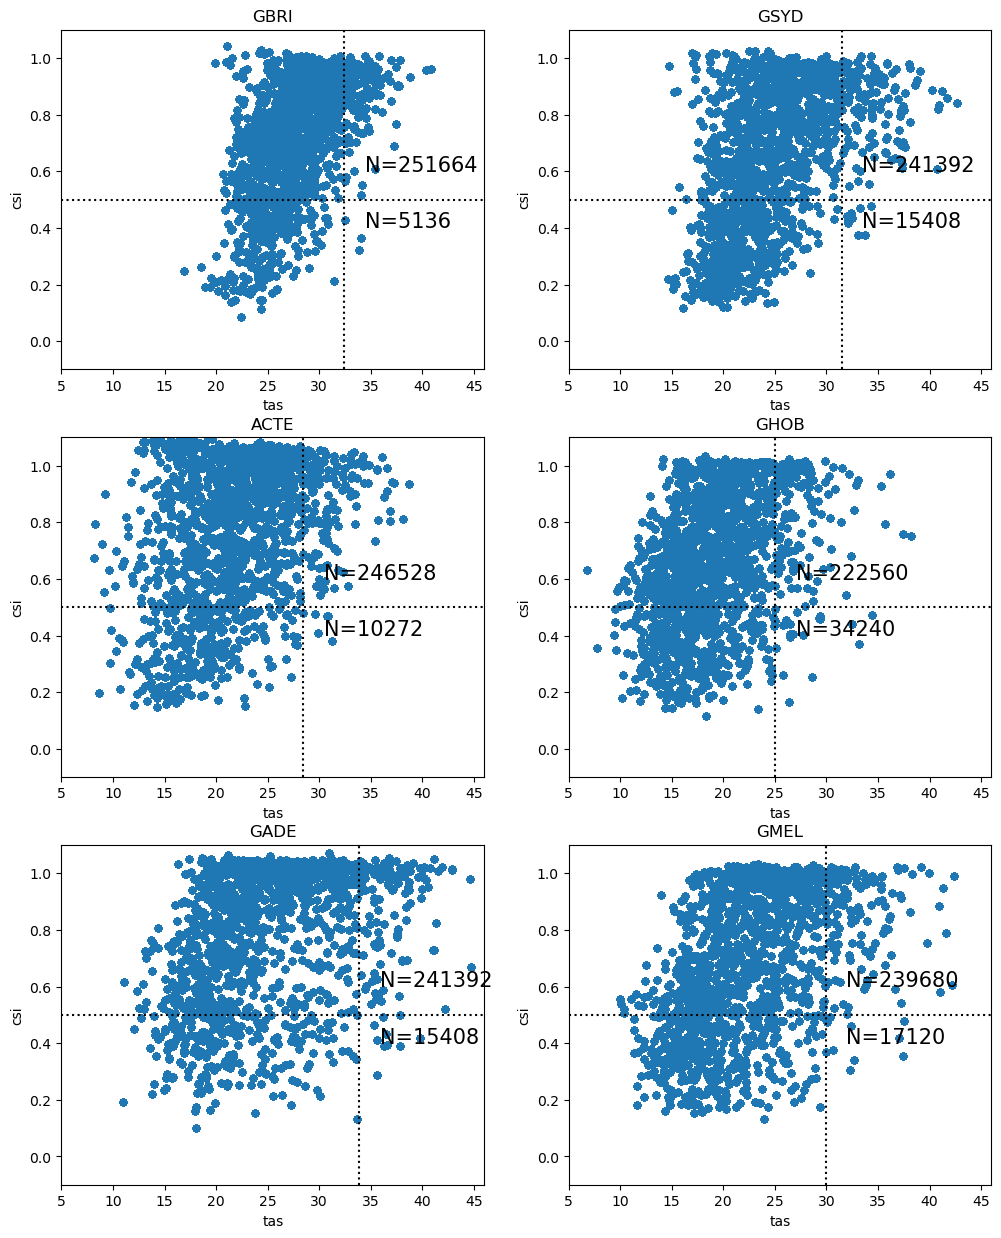

In [59]:
#For each region, plot a scatter plot showing the relationship between the afternoon minimum CSI and daily max temperature

#Highlight possible thresholds of 0.5 for afternoon minimum CSI and 90th percentile for temperature, that could be used to define 
# hot, low solar/cloudy days

regions = CSI_integrated.region.values
plt.figure(figsize=[12,15])

cnt=1
for r in regions:
    ax=plt.subplot(3,2,cnt)

    df.loc[r].plot(kind="scatter",x="tas",y="csi",ax=ax)

    thresh_tasmax = df.loc[r].tas.quantile(0.9)
    thresh_csi=0.5
    ax.axhline(thresh_csi,color="k",ls=":")
    ax.axvline(thresh_tasmax,color="k",ls=":")

    ax.text(
        thresh_tasmax + 2,
        thresh_csi - 0.1,
        "N="+str(((df.loc[r].csi < thresh_csi) & (df.loc[r].tas >= thresh_tasmax)).sum()),size=15)    

    ax.text(
        thresh_tasmax + 2,
        thresh_csi + 0.1,
        "N="+str(((df.loc[r].csi > thresh_csi) & (df.loc[r].tas >= thresh_tasmax)).sum()),size=15)    

    plt.title(r)

    plt.ylim([-0.1,1.1])
    plt.xlim([5,46])
    
    cnt+=1

## For each set of days, plot the distribution of CSI and capacity fator for each hour of the day

In [63]:
temp_dates

MultiIndex([('2016-01-23', 2015-11-01),
            ('2016-01-23', 2015-11-02),
            ('2016-01-23', 2015-11-03),
            ('2016-01-23', 2015-11-04),
            ('2016-01-23', 2015-11-05),
            ('2016-01-23', 2015-11-06),
            ('2016-01-23', 2015-11-07),
            ('2016-01-23', 2015-11-08),
            ('2016-01-23', 2015-11-09),
            ('2016-01-23', 2015-11-10),
            ...
            ('2020-12-07', 2025-01-22),
            ('2020-12-07', 2025-01-23),
            ('2020-12-07', 2025-01-24),
            ('2020-12-07', 2025-01-25),
            ('2020-12-07', 2025-01-26),
            ('2020-12-07', 2025-01-27),
            ('2020-12-07', 2025-01-28),
            ('2020-12-07', 2025-01-29),
            ('2020-12-07', 2025-01-30),
            ('2020-12-07', 2025-01-31)],
           names=['time', 'date'], length=5136)

In [60]:
#Create a list of hot, low solar (cloudy) days and hot, high solar (non-cloudy) days based on the thresholds in the above cell

hot_cloudy_dates = []
hot_noncloudy_dates = []
for r in regions:
    temp_df = df.loc[r]

    thresh_tasmax = temp_df.tas.quantile(0.9)
    thresh_csi = 0.5
    
    temp_dates = temp_df.loc[(temp_df.csi < thresh_csi) & (temp_df.tas >= thresh_tasmax)].index
    hot_cloudy_dates.append(pd.to_datetime(temp_dates))

    temp_dates = temp_df.loc[(temp_df.csi >= thresh_csi) & (temp_df.tas >= thresh_tasmax)].index
    hot_noncloudy_dates.append(pd.to_datetime(temp_dates))

hot_cloudy_dates = dict(zip(regions,hot_cloudy_dates))
hot_noncloudy_dates = dict(zip(regions,hot_noncloudy_dates))

TypeError: <class 'tuple'> is not convertible to datetime, at position 0

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

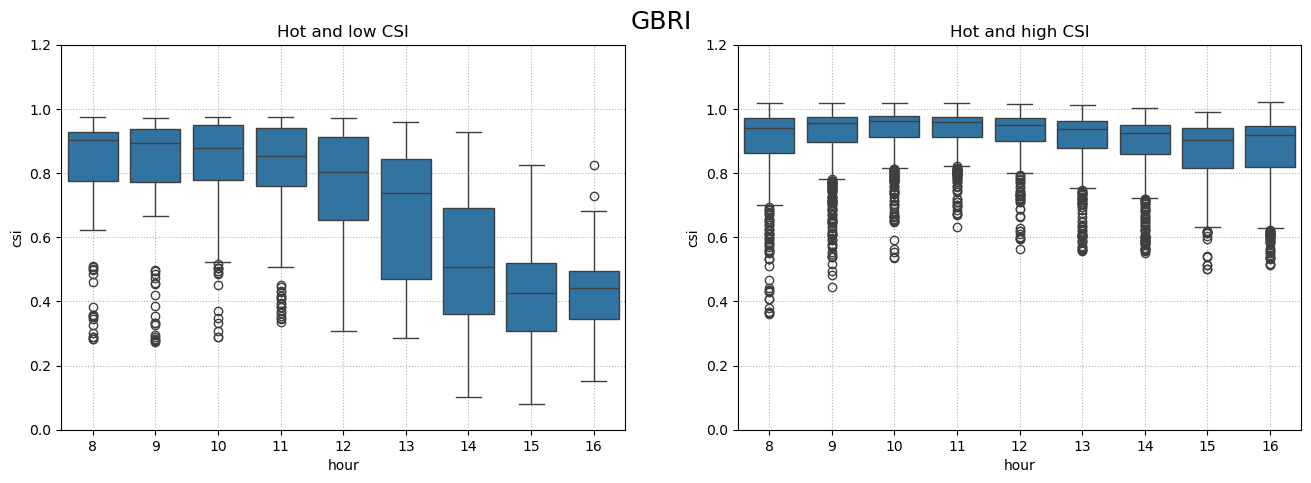

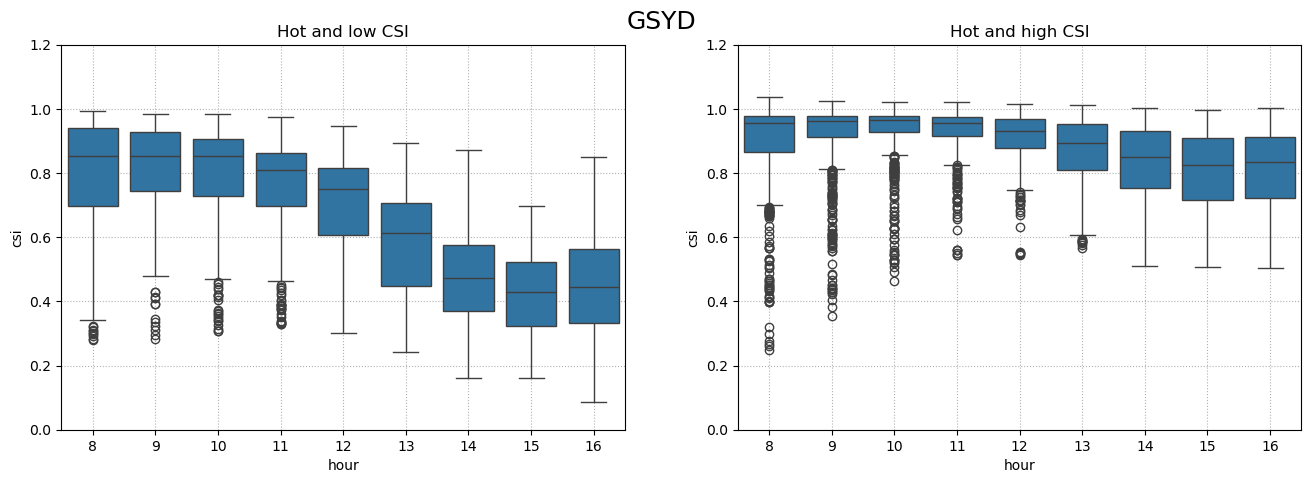

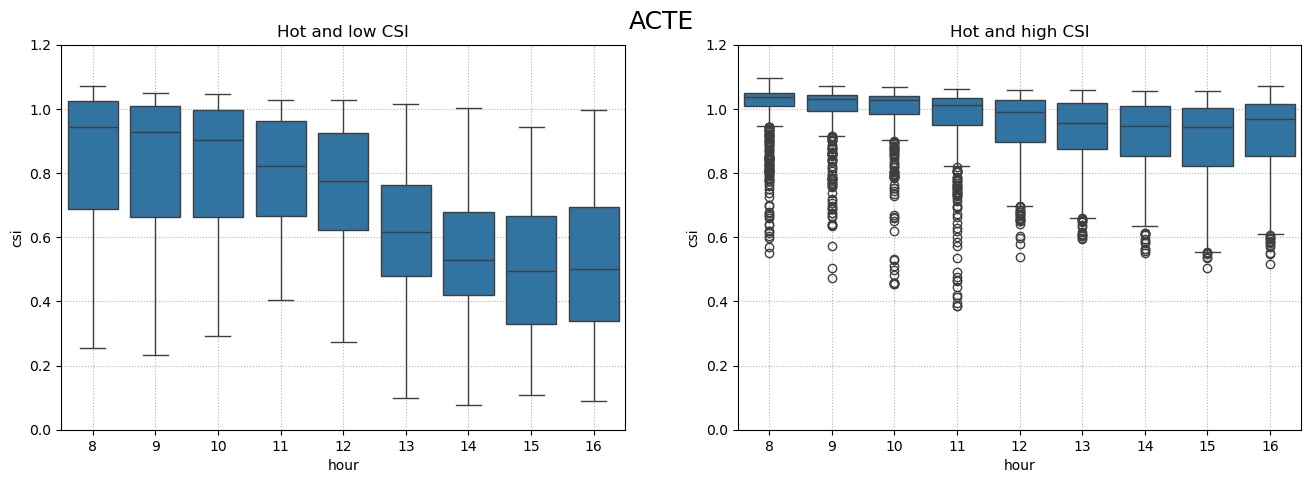

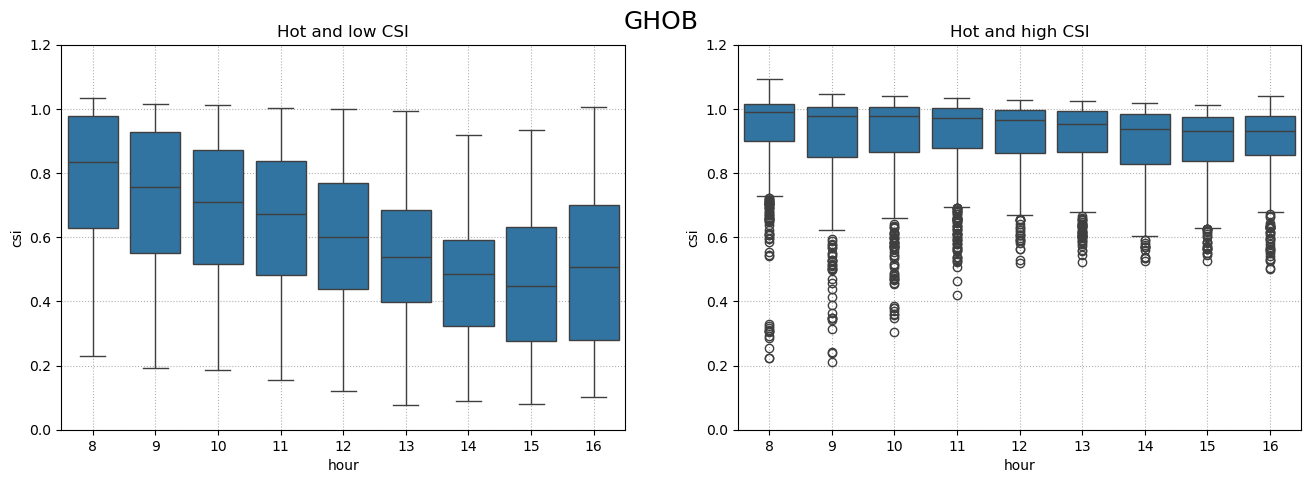

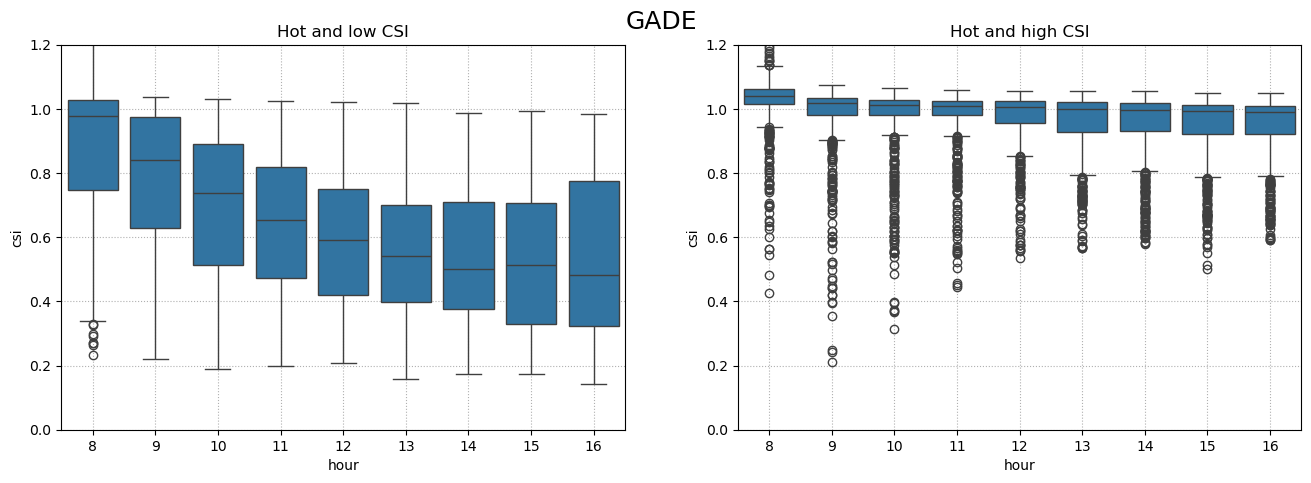

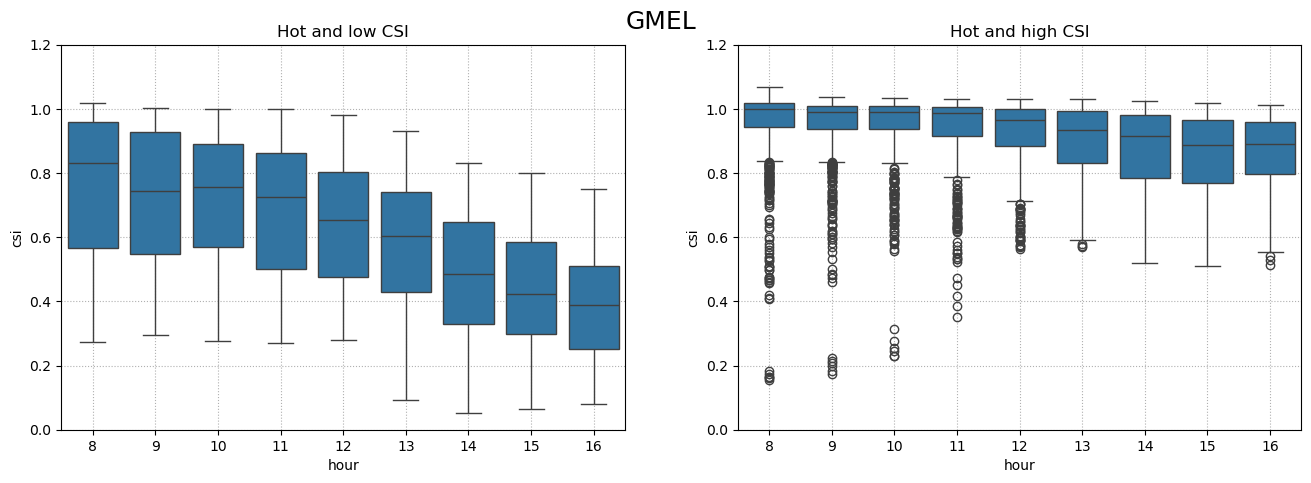

In [12]:
#For each region, plot the distribution of CSI for each our of the day, for the set of 
# hot, low solar days and hot, high solar days

for r in regions:

    plt.figure(figsize=[16,5])

    plt.subplot(1,2,1)
    temp_df = CSI.sel(
        region=r,
        time=(np.in1d(CSI.time.dt.date,hot_cloudy_dates[r].date) &\
              ((CSI.time.dt.hour >= 8) & (CSI.time.dt.hour < 17)))).to_dataframe(name="csi")
    temp_df["hour"] = temp_df.index.hour
    sns.boxplot(x="hour",y="csi",data=temp_df)
    plt.ylim([0,1.2])
    plt.title("Hot and low CSI")
    plt.gca().grid(ls=":")

    plt.subplot(1,2,2)
    temp_df = CSI.sel(
        region=r,
        time=(np.in1d(CSI.time.dt.date,hot_noncloudy_dates[r].date) &\
              ((CSI.time.dt.hour >= 8) & (CSI.time.dt.hour < 17)))).to_dataframe(name="csi")
    temp_df["hour"] = temp_df.index.hour
    sns.boxplot(x="hour",y="csi",data=temp_df)
    plt.ylim([0,1.2])
    plt.title("Hot and high CSI")
    plt.gca().grid(ls=":")
    
    plt.suptitle(r,y=0.95,size=18)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

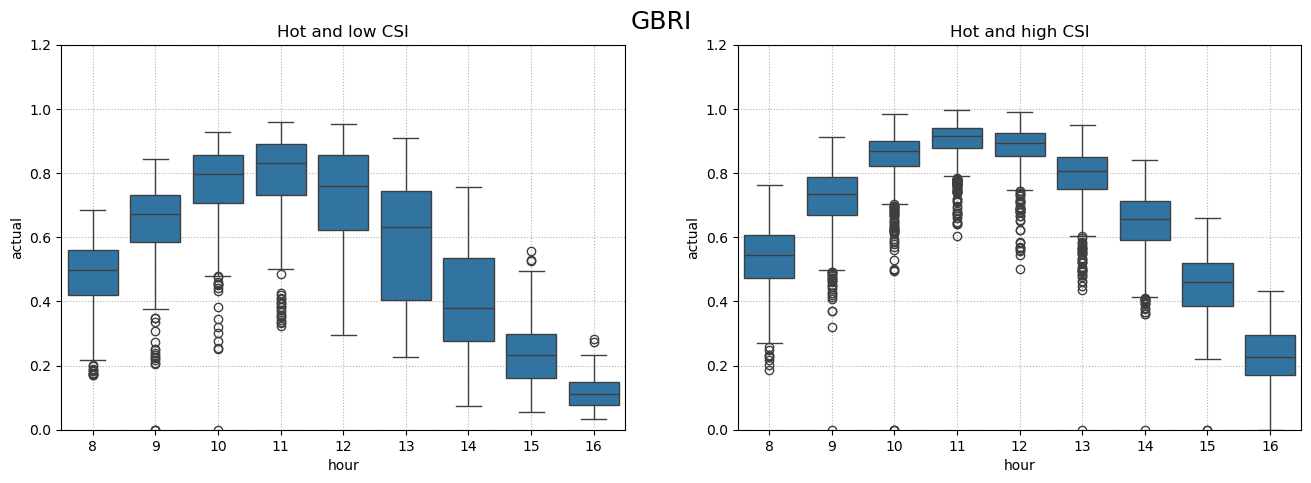

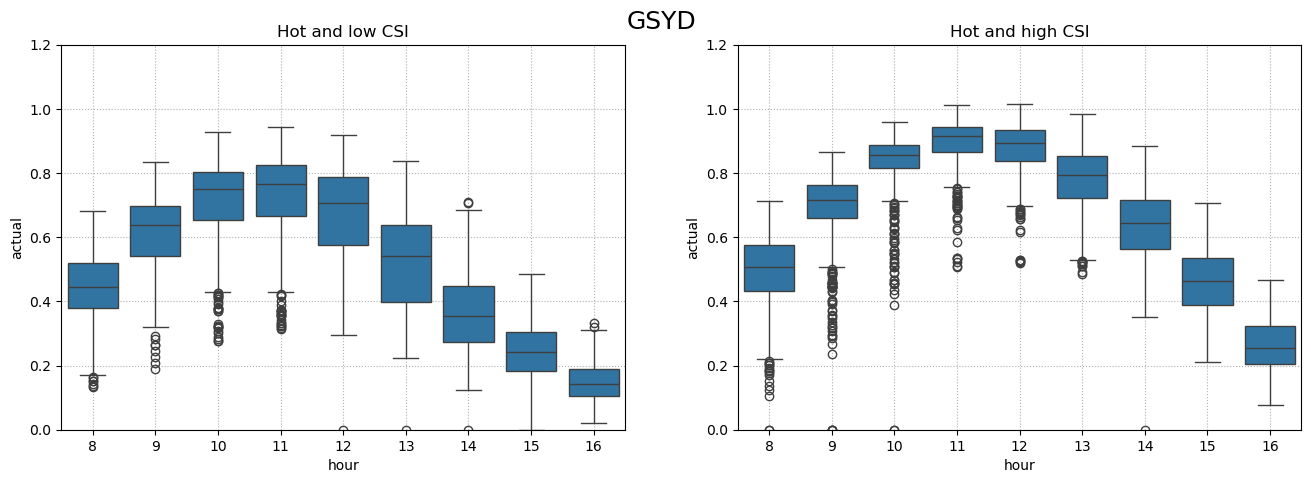

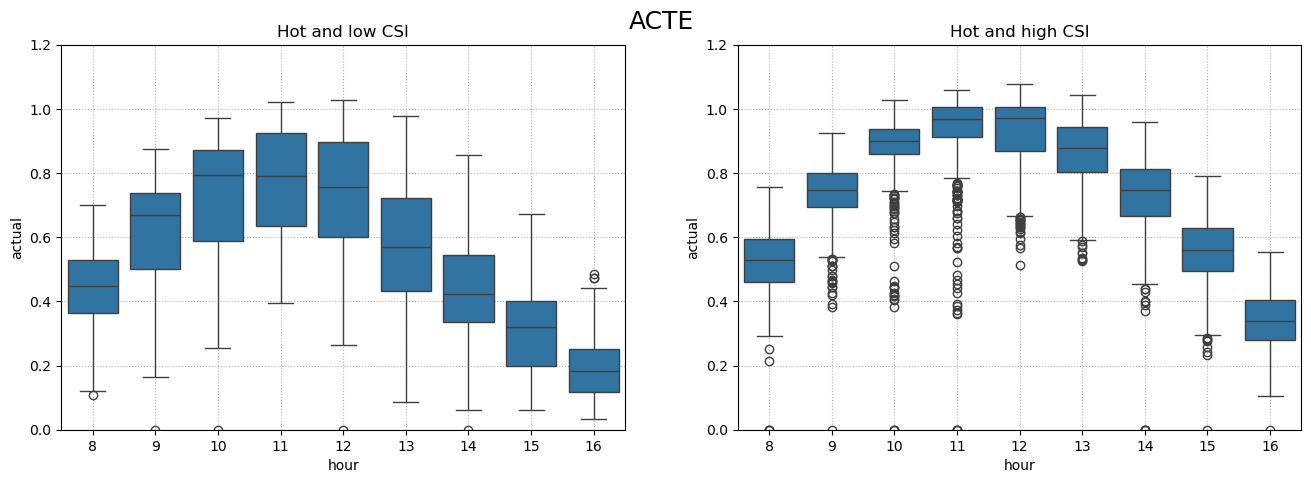

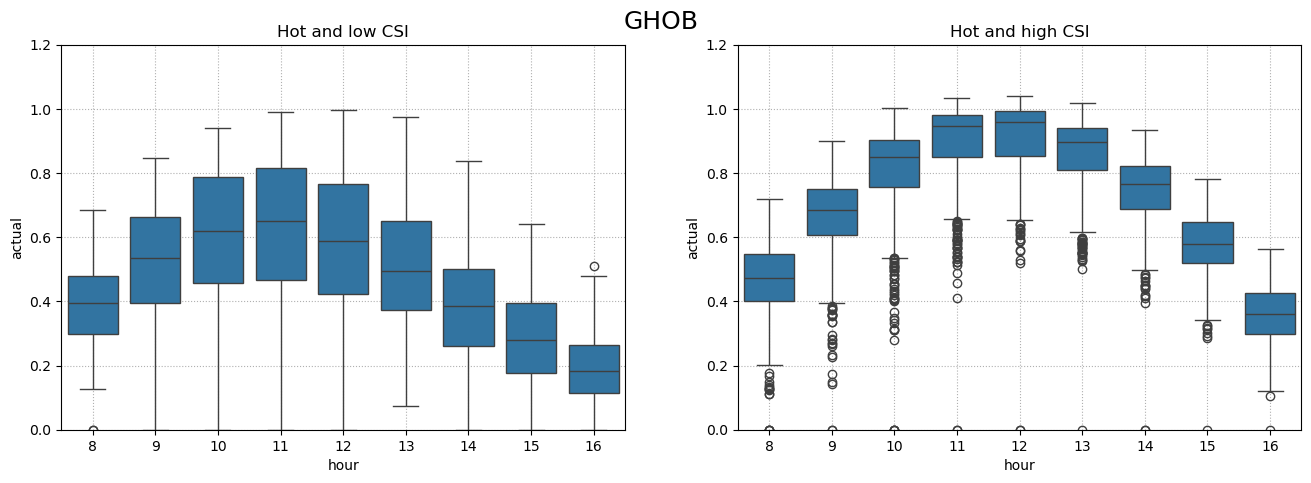

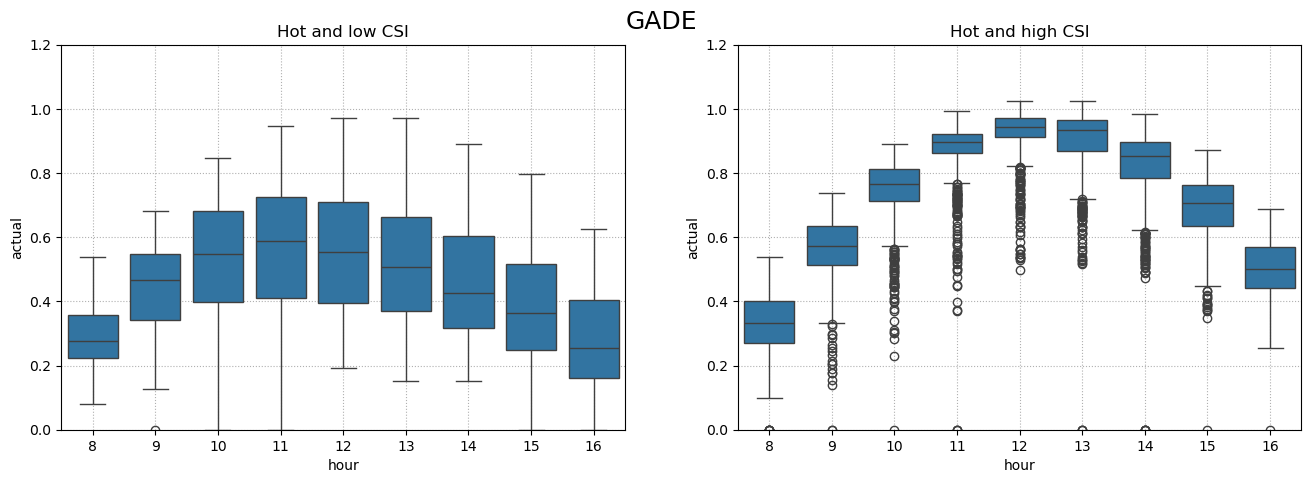

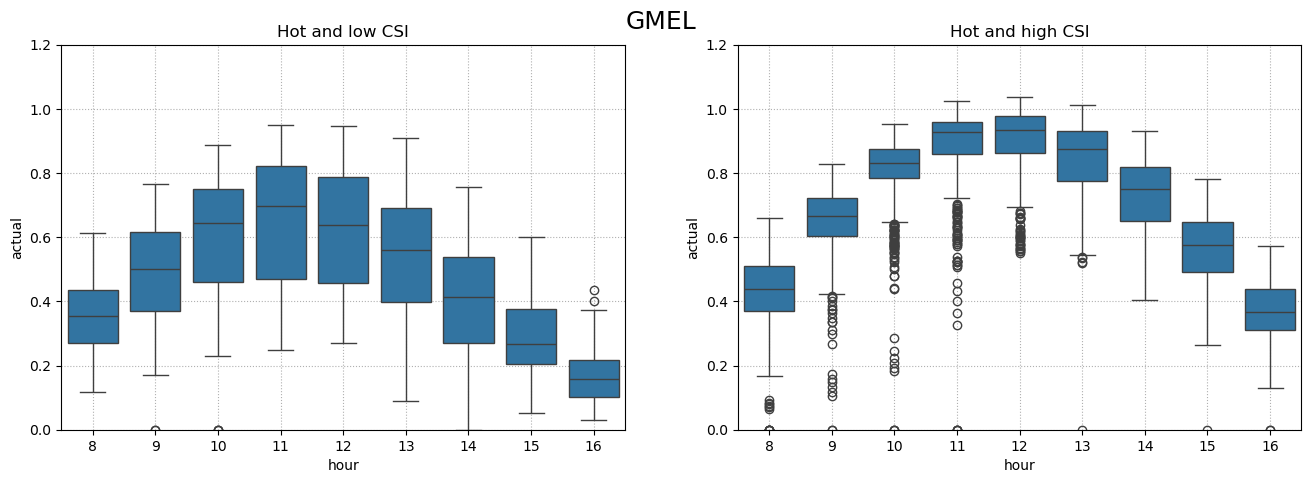

In [13]:
#For each region, plot the distribution of capacity factor for each our of the day, for the set of 
# hot, low solar days and hot, high solar days

for r in regions:

    plt.figure(figsize=[16,5])

    plt.subplot(1,2,1)
    temp_df = ds.sel(
        region=r,
        time=(np.in1d(ds.time.dt.date,hot_cloudy_dates[r].date) &\
              ((ds.time.dt.hour >= 8) & (ds.time.dt.hour < 17)))).actual.to_dataframe(name="actual")
    temp_df["hour"] = temp_df.index.hour
    sns.boxplot(x="hour",y="actual",data=temp_df)
    plt.ylim([0,1.2])
    plt.title("Hot and low CSI")
    plt.gca().grid(ls=":")

    plt.subplot(1,2,2)
    temp_df = ds.sel(
        region=r,
        time=(np.in1d(ds.time.dt.date,hot_noncloudy_dates[r].date) &\
              ((ds.time.dt.hour >= 8) & (ds.time.dt.hour < 17)))).actual.to_dataframe(name="actual")
    temp_df["hour"] = temp_df.index.hour
    sns.boxplot(x="hour",y="actual",data=temp_df)
    plt.ylim([0,1.2])
    plt.title("Hot and high CSI")
    plt.gca().grid(ls=":")
    
    plt.suptitle(r,y=0.95,size=18)

In [14]:
print(hot_cloudy_dates["GMEL"])

DatetimeIndex(['2015-11-25', '2015-12-19', '2015-12-20', '2016-01-11',
               '2016-02-23', '2016-03-04', '2016-11-21', '2016-12-04',
               '2016-12-13', '2017-12-19', '2018-01-26', '2018-01-29',
               '2018-02-23', '2018-03-17', '2018-12-07', '2018-12-08',
               '2019-01-17', '2019-01-30', '2019-02-06', '2019-03-03',
               '2019-11-21', '2019-12-30', '2020-01-10', '2020-01-15',
               '2020-01-31', '2020-12-15', '2021-01-25', '2021-02-11',
               '2022-01-28', '2022-02-13', '2023-01-28', '2023-03-18',
               '2023-12-08'],
              dtype='datetime64[ns]', name='time', freq=None)


In [15]:
print(hot_cloudy_dates["GSYD"])

DatetimeIndex(['2016-01-14', '2016-01-21', '2016-11-22', '2016-12-02',
               '2016-12-05', '2016-12-14', '2016-12-30', '2017-01-24',
               '2017-01-31', '2017-02-05', '2017-02-12', '2017-02-17',
               '2017-12-18', '2017-12-20', '2017-12-24', '2017-12-29',
               '2018-01-08', '2018-01-09', '2018-01-22', '2018-01-23',
               '2018-01-24', '2018-02-09', '2018-12-20', '2018-12-31',
               '2019-01-02', '2019-01-05', '2019-01-23', '2019-01-27',
               '2019-03-06', '2019-12-10', '2019-12-19', '2020-01-23',
               '2020-01-26', '2020-01-28', '2020-02-02', '2020-03-02',
               '2020-11-16', '2020-11-29', '2021-12-19', '2023-01-26',
               '2023-01-29', '2023-02-18'],
              dtype='datetime64[ns]', name='time', freq=None)


In [16]:
print(hot_cloudy_dates["GBRI"])

DatetimeIndex(['2015-12-11', '2016-01-23', '2016-01-29', '2016-02-02',
               '2016-11-08', '2016-11-12', '2016-12-03', '2016-12-07',
               '2016-12-21', '2017-02-13', '2018-02-11', '2018-02-15',
               '2018-02-16', '2019-03-11', '2019-12-11', '2020-01-11',
               '2020-01-21', '2020-01-22', '2020-11-17', '2020-11-24',
               '2020-12-07', '2021-01-16', '2021-02-23', '2023-02-03',
               '2023-11-15'],
              dtype='datetime64[ns]', name='time', freq=None)


In [17]:
print(hot_cloudy_dates["GADE"])

DatetimeIndex(['2015-12-15', '2015-12-19', '2015-12-25', '2016-01-10',
               '2016-01-11', '2016-01-13', '2016-01-19', '2016-02-22',
               '2016-02-23', '2016-03-06', '2016-12-13', '2017-01-07',
               '2017-11-29', '2017-12-13', '2017-12-27', '2018-01-11',
               '2018-01-21', '2018-01-27', '2018-01-28', '2018-11-19',
               '2018-12-28', '2019-01-11', '2019-01-16', '2019-01-17',
               '2019-12-20', '2020-11-10', '2020-11-22', '2021-01-11',
               '2021-02-11', '2021-02-19', '2022-01-10', '2023-01-14',
               '2023-01-17', '2023-12-08'],
              dtype='datetime64[ns]', name='time', freq=None)


In [22]:
gmel = pd.DataFrame(hot_cloudy_dates["GMEL"])
gmel["region"] = "GMEL"

gsyd = pd.DataFrame(hot_cloudy_dates["GSYD"])
gsyd["region"] = "GSYD"

gbri = pd.DataFrame(hot_cloudy_dates["GBRI"])
gbri["region"] = "GBRI"

gade = pd.DataFrame(hot_cloudy_dates["GADE"])
gade["region"] = "GADE"

In [25]:
pd.concat([gmel,gsyd,gade,gbri],axis=0).to_csv("/g/data/ng72/ab4502/hot-cloudy/data/event_dates_csi0p5_tmax90.csv")

,time,region
0,2015-11-25,GMEL
1,2015-12-19,GMEL
2,2015-12-20,GMEL
3,2016-01-11,GMEL
4,2016-02-23,GMEL
...,...,...
20,2020-12-07,GBRI
21,2021-01-16,GBRI
22,2021-02-23,GBRI
23,2023-02-03,GBRI
